# Pandas 실습 2

### 1. 데이터 준비
- 서울시 공공자전거(따릉이) 대여 데이터

In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd
import numpy as np

In [94]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('NumPy 버전:', np.__version__)
print('환경 설정 완료')

NumPy 버전: 2.3.5
환경 설정 완료


In [3]:
# 데이터 로드
df1 = pd.read_csv('data/서울특별시 공공자전거 일별 대여건수.csv')
df1.head()

,대여일자,대여건수
0,2025-07-01,132914
1,2025-07-02,151653
2,2025-07-03,151092
3,2025-07-04,151367
4,2025-07-05,118354


In [4]:
# 데이터 로드
df2 = pd.read_excel('data/대여소별 반납내역(2017년).xlsx')
df2.head()

,대여소 그룹,대여소 명,반납 일자 / 월,반납 건수
0,그룹명 없음,대여소명 없음,2017-01-01,10
1,광진구,500. 어린이대공원역 3번출구 앞,2017-01-01,12
2,광진구,501. 광진구의회 앞,2017-01-01,10
3,광진구,502. 뚝섬유원지역 1번출구 앞,2017-01-01,13
4,광진구,503. 더샵스타시티 C동 앞,2017-01-01,8


In [5]:
# df1의 일자별 대여건수 top10
df1['대여일자'].value_counts()
df1['대여일자'].dtypes

dtype('O')

In [6]:
# '대여일자' 데이터 타입 변환, to_datetime()
df1['대여일자'] = pd.to_datetime(df1['대여일자'])
df1.dtypes
df1['Year'] = df1['대여일자'].dt.year
df1['Month'] = df1['대여일자'].dt.month
df1['Day'] = df1['대여일자'].dt.day
df1['Month'].value_counts()

Month
7     31
8     31
10    31
12    31
9     30
11    30
Name: count, dtype: int64

In [7]:
# df1의 2025년도 월별 대여건수
df1_rentals = df1.groupby('Month')['Month'].sum()
df1_rentals.index
df1_rentals.values

array([217, 248, 270, 310, 330, 372], dtype=int32)

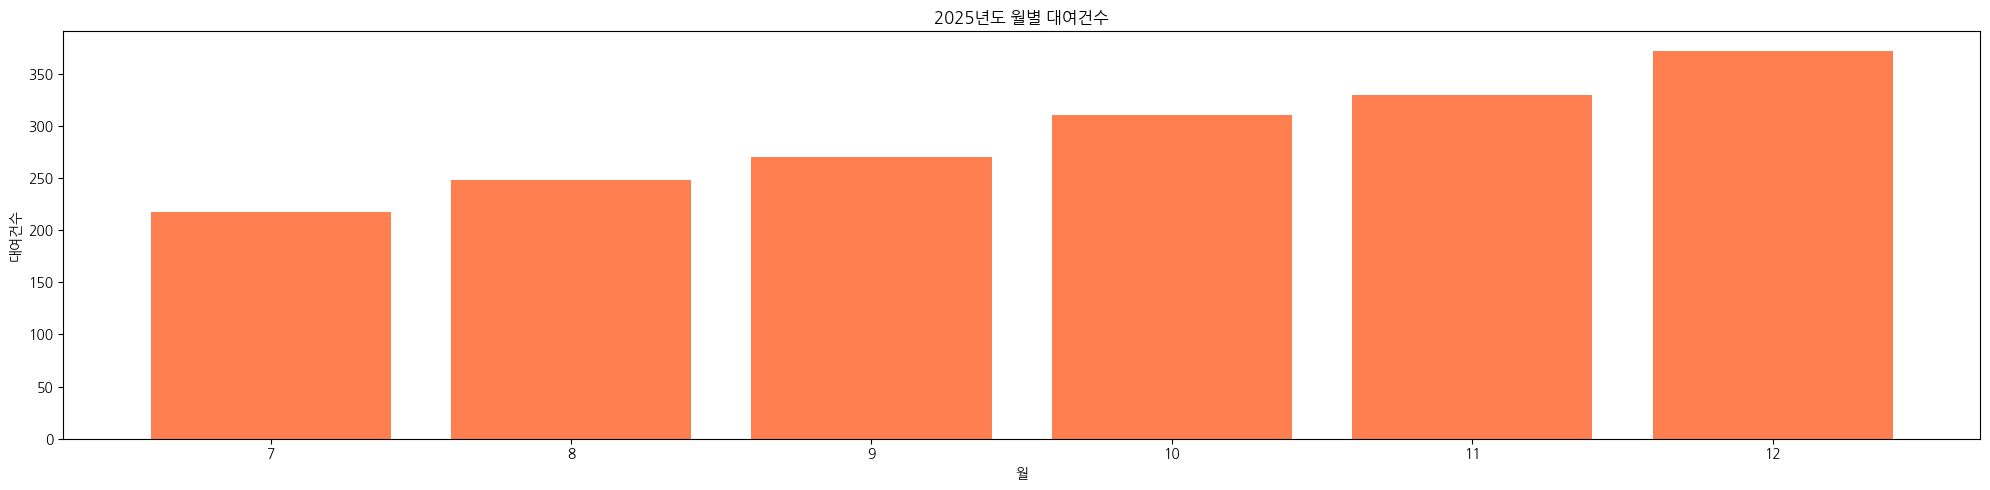

In [8]:
# 막대 그래프
plt.figure(figsize=(20, 5))
plt.bar(df1_rentals.index, df1_rentals.values, color='coral')
plt.title('2025년도 월별 대여건수')
plt.xlabel('월')
plt.ylabel('대여건수')
# plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- 요일별 대여건수 그래프 시각화

In [16]:
# 0:월요일 1:화요일
# 'weekday' 컬럼을 생성하고 요일 정보를 저장
df1['weekday'] = df1['대여일자'].dt.weekday
df1

,대여일자,대여건수,Year,Month,Day,weekday
0,2025-07-01,132914,2025,7,1,1
1,2025-07-02,151653,2025,7,2,2
2,2025-07-03,151092,2025,7,3,3
3,2025-07-04,151367,2025,7,4,4
4,2025-07-05,118354,2025,7,5,5
...,...,...,...,...,...,...
179,2025-12-27,42381,2025,12,27,5
180,2025-12-28,40774,2025,12,28,6
181,2025-12-29,66652,2025,12,29,0
182,2025-12-30,71026,2025,12,30,1


In [21]:
# 요일을 매핑하는 딕셔너리 생성
week_dict = {
    0: '월',
    1: '화',
    2: '수',
    3: '목',
    4: '금',
    5: '토',
    6: '일',
}
df1['weekday'] = df1['대여일자'].dt.weekday.map(week_dict)
df1.head(3)

,대여일자,대여건수,Year,Month,Day,weekday
0,2025-07-01,132914,2025,7,1,화
1,2025-07-02,151653,2025,7,2,수
2,2025-07-03,151092,2025,7,3,목


In [34]:
# 요일별 대여건수 그래프 생성
order = ['월','화','수','목','금','토','일',]
df1['weekday'].value_counts()
result = df1.groupby('weekday')['대여건수'].sum().reindex(order).reset_index()
result['weekday']

0    월
1    화
2    수
3    목
4    금
5    토
6    일
Name: weekday, dtype: object

In [ ]:
plt.figure(figsize=(20, 5))
plt.bar(result.index, result.values, color='gray')
plt.title('요일별 대여 건수')
plt.xlabel('요일')
plt.ylabel('대여건수')
plt.show()

In [40]:
# df2의 대여소별 대여건수 top5
df2.head()
df2.shape
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245446 entries, 0 to 245445
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   대여소 그룹     245446 non-null  object        
 1   대여소 명      245446 non-null  object        
 2   반납 일자 / 월  245446 non-null  datetime64[ns]
 3   반납 건수      245446 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 7.5+ MB


In [ ]:
# df2 컬럼명 수정
df2.rename(columns = {'대여소 그룹':'그룹'})
df2.columns = ['그룹', '대여소', '일자', '건수']
df2

In [50]:
# 대여소별 대여건수 Top5
df2['대여소'].value_counts()
station_top5 = df2.groupby('대여소')['건수'].sum().sort_values(ascending=False).head(5)
station_top5

대여소
207. 여의나루역 1번출구 앞     52750
113. 홍대입구역 2번출구 앞     50339
502. 뚝섬유원지역 1번출구 앞    44158
152. 마포구민체육센터 앞       31476
907. CJ 드림시티          27075
Name: 건수, dtype: int64

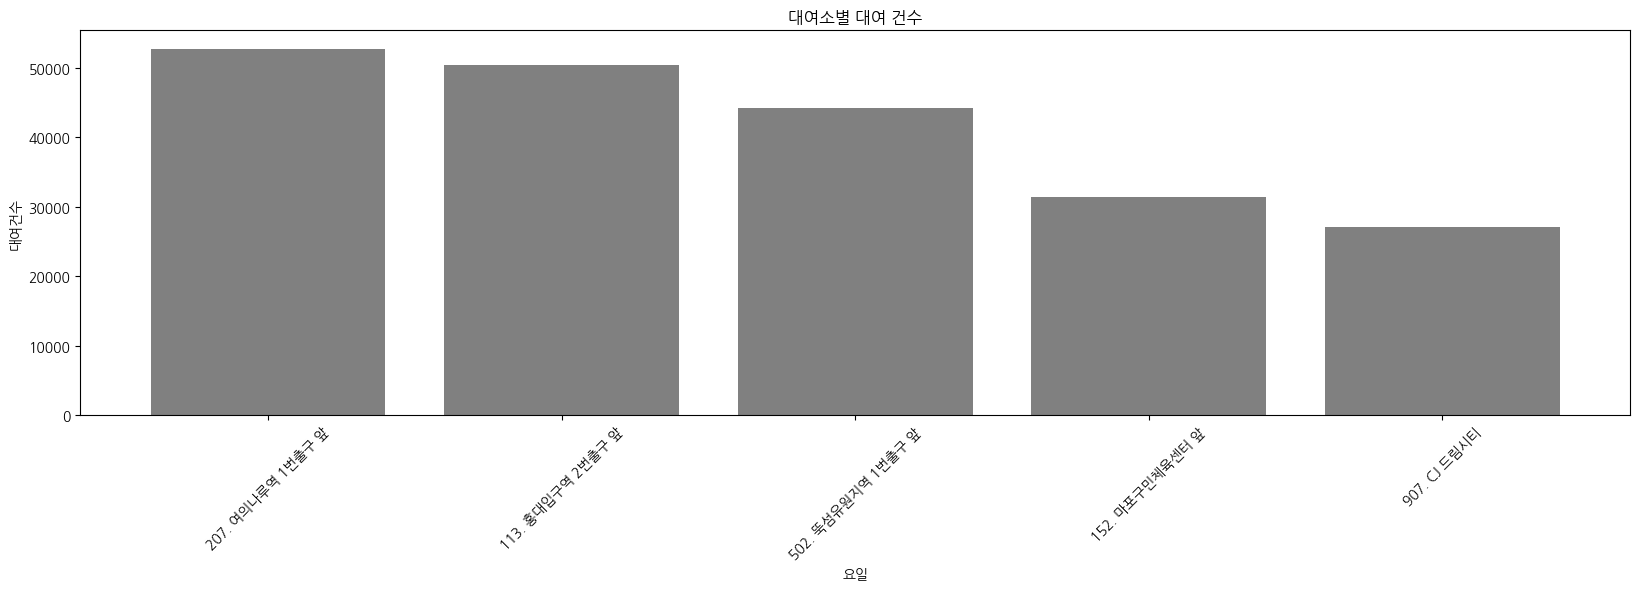

In [53]:
plt.figure(figsize=(20, 5))
plt.bar(station_top5.index, station_top5.values, color='gray')
plt.title('대여소별 대여 건수')
plt.xlabel('요일')
plt.ylabel('대여건수')
plt.xticks(rotation=45)
plt.show()

- 그룹별 총 대여건수 Top10

In [60]:
group_top10 = df2.groupby('그룹')['건수'].sum().sort_values(ascending=False).head(10)
group_top10

그룹
마포구     788652
영등포구    639773
종로구     459280
성동구     374713
광진구     305663
서대문구    288012
동대문구    252585
중구      224510
은평구     197490
송파구     162371
Name: 건수, dtype: int64

In [ ]:
group_top10.plot(
    kind='bar',
    figsize=(10, 5)
)
plt.title('자치구별 대여건수 Top10')
plt.ylabel('대여건수')
plt.show()

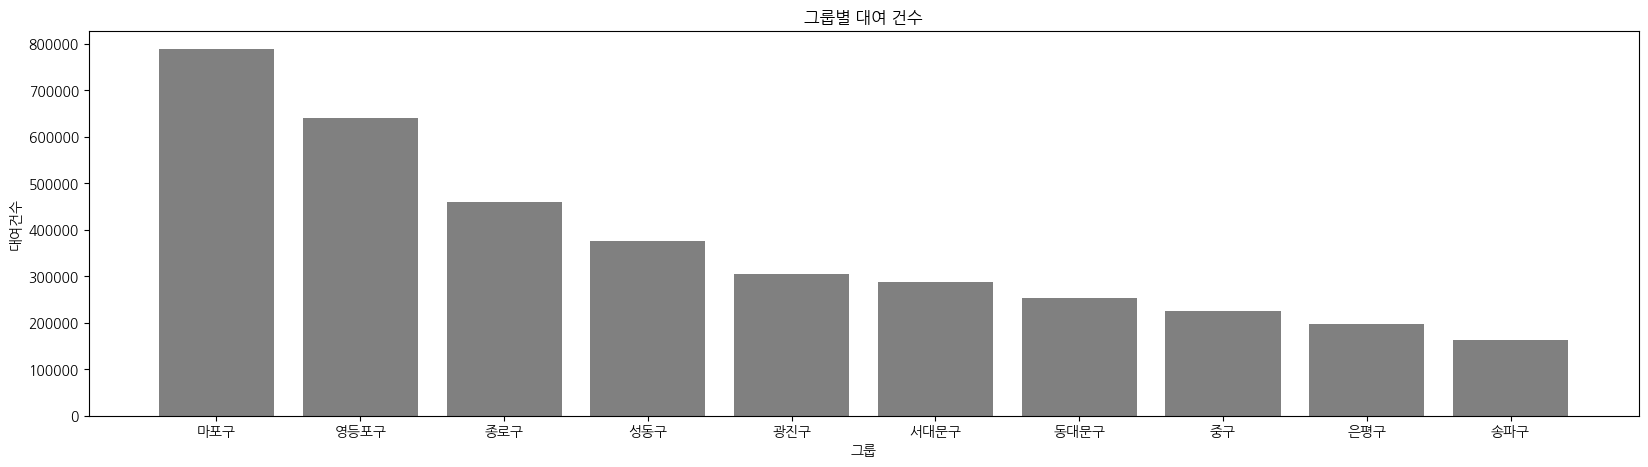

In [63]:
plt.figure(figsize=(20, 5))
plt.bar(group_top10.index, group_top10.values, color='gray')
plt.title('그룹별 대여 건수')
plt.xlabel('그룹')
plt.ylabel('대여건수')
# plt.xticks(rotation=45)
plt.show()

- 월별 전체 대여건수 Top10

In [82]:
df2['월'] = df2['일자'].dt.month
month_rent = df2.groupby('월')['건수'].sum()
month_rent

월
1      84149
2      85752
3     188767
4     319181
5     451223
6     536705
7     388664
8     540559
9     889873
10    863104
11    482618
12    200436
Name: 건수, dtype: int64

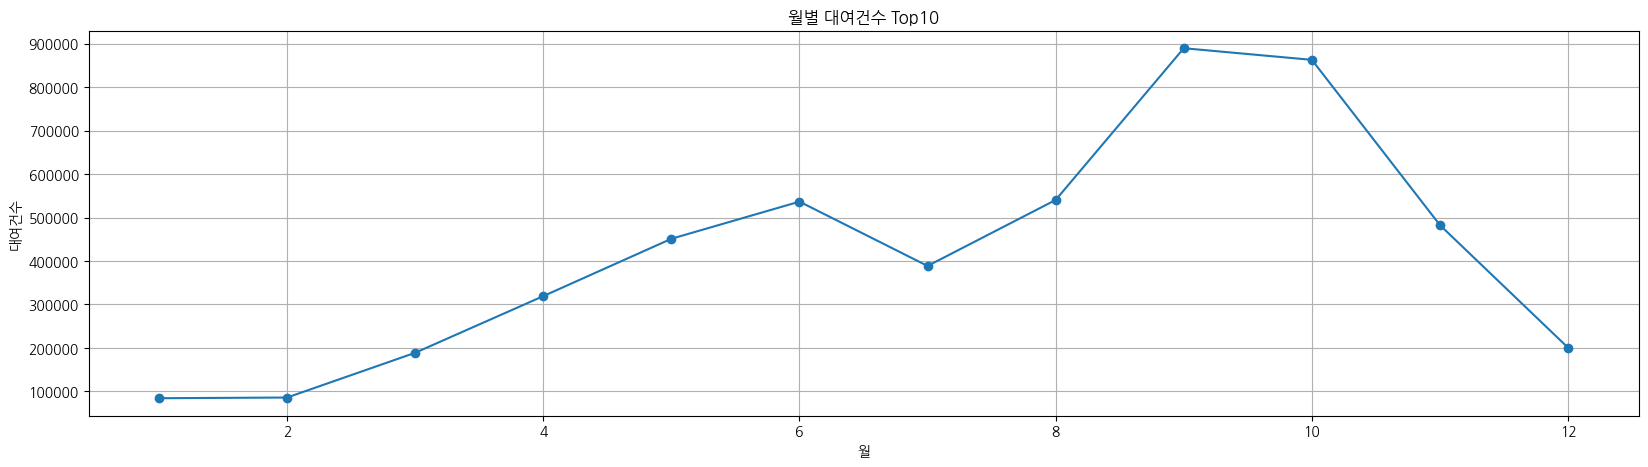

In [88]:
month_rent.plot(
    kind='line',
    marker = 'o',
    figsize=(20, 5)
)
plt.title('월별 대여건수 Top10')
plt.ylabel('대여건수')
plt.grid()
plt.show()

In [ ]:
df2['대여일자'] = pd.to_datetime(df2['대여일자'])
df2.dtypes
df2['Year'] = df2['대여일자'].dt.year
df2['Month'] = df2['대여일자'].dt.month
df2['Day'] = df2['대여일자'].dt.day
df2['Month'].value_counts()

In [ ]:
month_top10 = df2.groupby('Month')['건수'].sum().sort_values(ascending=False).head(10)
month_top10

In [ ]:
plt.figure(figsize=(20, 5))
plt.bar(month_top10.index, month_top10.values, color='gray')
plt.title('월별 대여 건수')
plt.xlabel('Month')
plt.ylabel('대여건수')
# plt.xticks(rotation=45)
plt.show()

- 대여소별 평균 대여건수 Top15

In [ ]:
group_mean = df2.groupby('대여소')['건수'].mean().sort_values(ascending=False).head(15)
group_mean

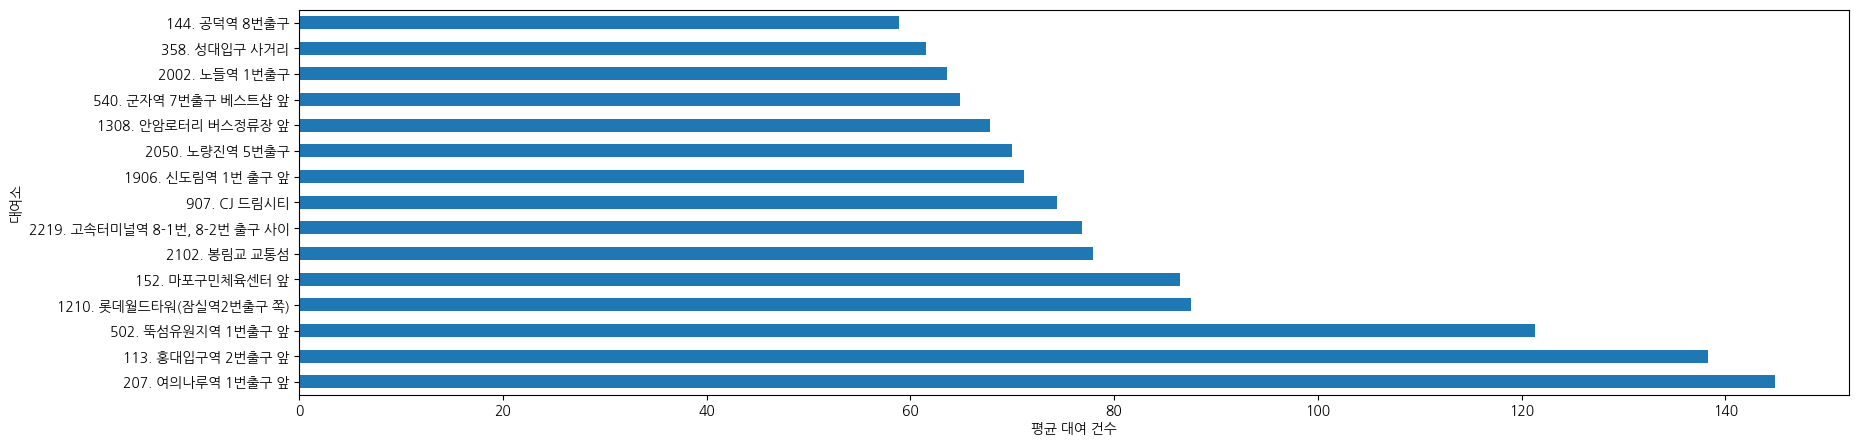

In [93]:
group_mean.plot(
    kind='barh',
    figsize=(20, 5)
)
plt.xlabel('평균 대여 건수')
# plt.title('월별 대여건수 Top10')
# plt.ylabel('대여건수')
# plt.grid()
plt.show()

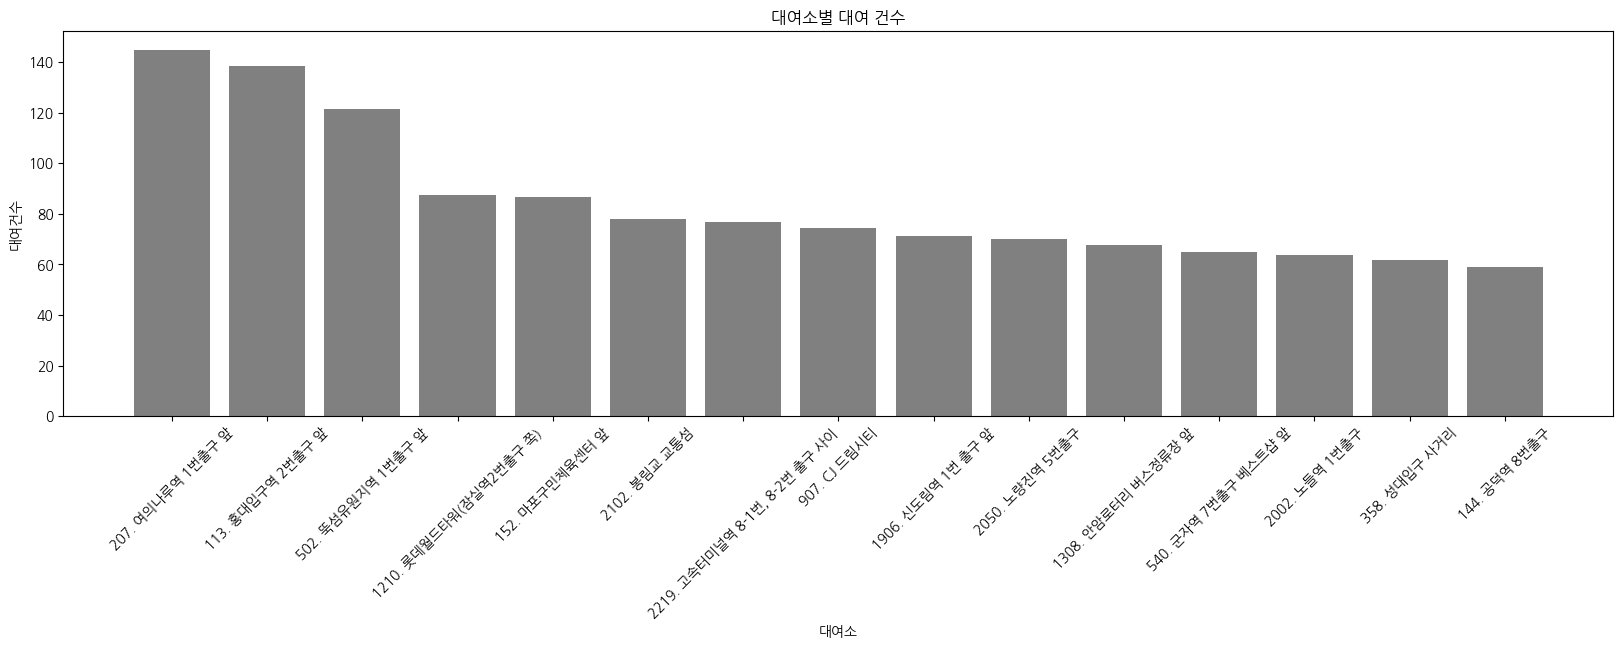

In [91]:
plt.figure(figsize=(20, 5))
plt.bar(group_mean.index, group_mean.values, color='gray')
plt.title('대여소별 대여 건수')
plt.xlabel('대여소')
plt.ylabel('대여건수')
plt.xticks(rotation=45)
plt.show()